**RECOMMENDATION ENGINE(END-TO-END)**

**1.PROBLEM STATEMENT**

1.Users find it difficult to discover relevant products due to too many options.

2.Lack of personalized recommendations reduces user engagement and sales.

3.Objective: Build a system to recommend Top-N items based on user behavior.

4.Enable data-driven personalized recommendations to improve user experience and business growth.

**2.DATA PREPROCESSING**

In [ ]:
import pandas as pd

def load_data(path):
    df = pd.read_csv(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.drop_duplicates()
    df = df.dropna()
    return df

def create_matrix(df):
    return df.pivot_table(
        index='user_id',
        columns='item_id',
        values='interaction'
    ).fillna(0)

**3.EDA**

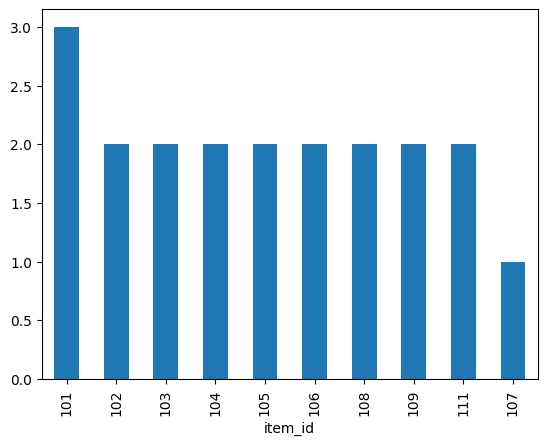

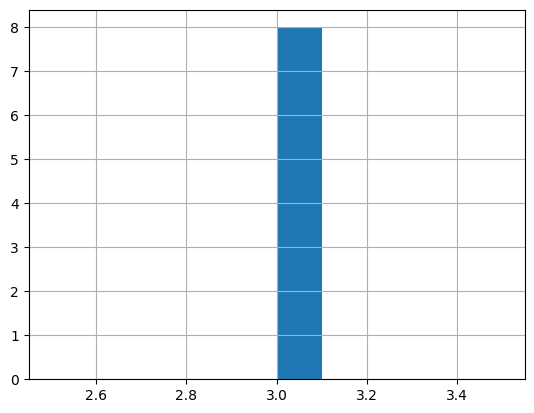

In [ ]:
import matplotlib.pyplot as plt

# Top items
df['item_id'].value_counts().head(10).plot(kind='bar')
plt.show()

# User activity
df.groupby('user_id').size().hist()
plt.show()

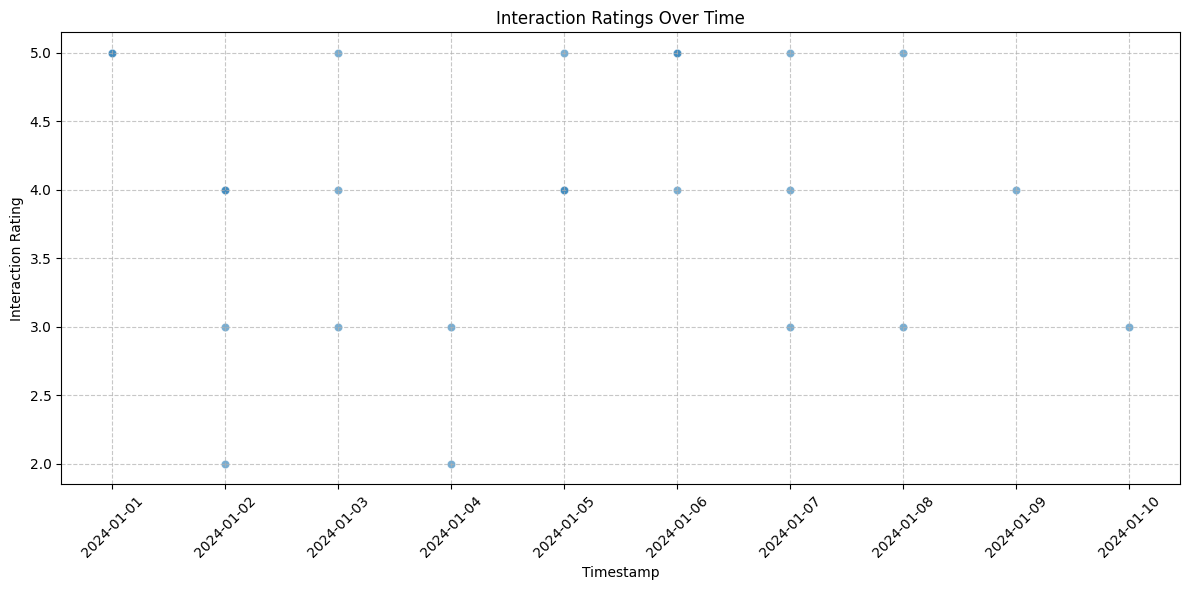

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(x='timestamp', y='interaction', data=df, alpha=0.6)
plt.title('Interaction Ratings Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Interaction Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df['timestamp_numeric'] = df['timestamp'].astype('int64') // 10**9  # Convert to Unix timestamp in seconds
correlation = df['interaction'].corr(df['timestamp_numeric'])
display(f"Correlation between interaction ratings and timestamp: {correlation:.4f}")

'Correlation between interaction ratings and timestamp: 0.0114'

In [ ]:
avg_interaction_per_category = df.groupby('category')['interaction'].mean().reset_index()
display(avg_interaction_per_category)

,category,interaction
0,books,4.000000
1,electronics,3.857143
2,fashion,4.000000
3,home,3.800000


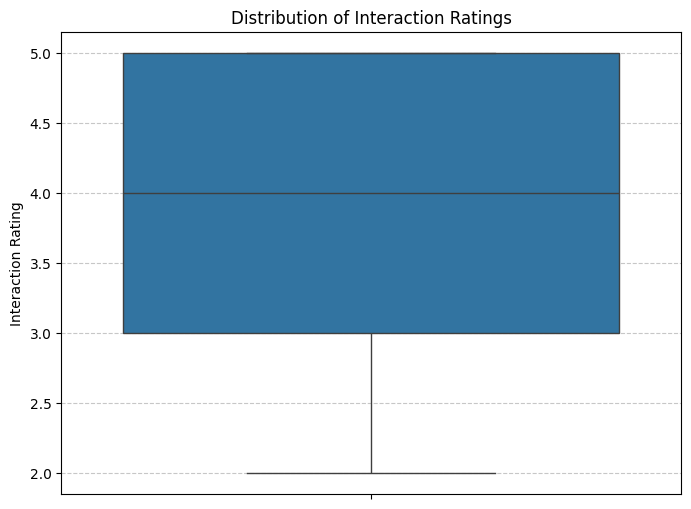

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['interaction'])
plt.title('Distribution of Interaction Ratings')
plt.ylabel('Interaction Rating')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
display(df['interaction'].describe())

,interaction
count,24.000000
mean,3.916667
std,0.974308
min,2.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


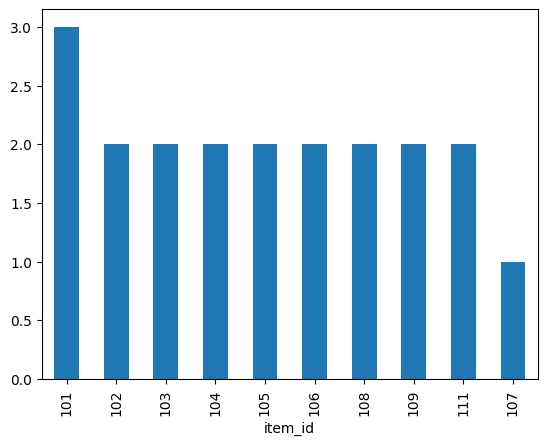

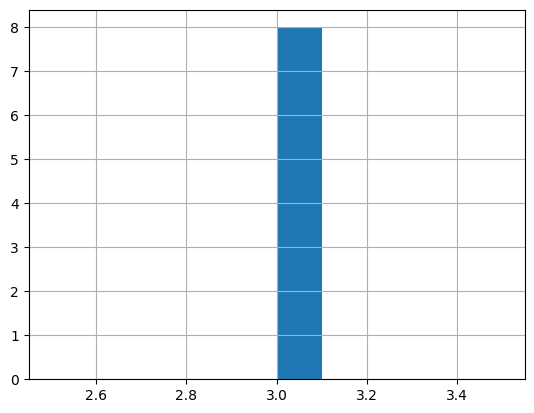

In [ ]:
import matplotlib.pyplot as plt

# Top items
df['item_id'].value_counts().head(10).plot(kind='bar')
plt.show()

# User activity
df.groupby('user_id').size().hist()
plt.show()

In [6]:
%%writefile /content/recommendation_data.csv
user_id,item_id,interaction,timestamp,category,description
1,101,5,"2023-01-01 10:00:00",Electronics,Smartphone
1,102,4,"2023-01-01 11:00:00",Electronics,Laptop
2,101,3,"2023-01-02 12:00:00",Electronics,Smartphone
2,103,5,"2023-01-02 13:00:00",Books,Fiction Book
3,102,5,"2023-01-03 14:00:00",Electronics,Laptop
3,104,4,"2023-01-03 15:00:00",Home,Coffee Maker
1,103,4,"2023-01-04 16:00:00",Books,Fiction Book
4,101,2,"2023-01-05 17:00:00",Electronics,Smartphone
4,105,5,"2023-01-05 18:00:00",Clothing,T-shirt
5,102,3,"2023-01-06 19:00:00",Electronics,Laptop
5,106,4,"2023-01-06 20:00:00",Sports,Running Shoes
1,104,3,"2023-01-07 21:00:00",Home,Coffee Maker
2,105,4,"2023-01-08 09:00:00",Clothing,T-shirt
3,106,5,"2023-01-09 10:00:00",Sports,Running Shoes
4,103,3,"2023-01-10 11:00:00",Books,Fiction Book
5,101,5,"2023-01-11 12:00:00",Electronics,Smartphone

Overwriting /content/recommendation_data.csv


In [5]:
%%writefile /content/recommendation_data.csv
user_id,item_id,interaction,timestamp,category,description
1,101,5,"2023-01-01 10:00:00",Electronics,Smartphone
1,102,4,"2023-01-01 11:00:00",Electronics,Laptop
2,101,3,"2023-01-02 12:00:00",Electronics,Smartphone
2,103,5,"2023-01-02 13:00:00",Books,Fiction Book
3,102,5,"2023-01-03 14:00:00",Electronics,Laptop
3,104,4,"2023-01-03 15:00:00",Home,Coffee Maker
1,103,4,"2023-01-04 16:00:00",Books,Fiction Book
4,101,2,"2023-01-05 17:00:00",Electronics,Smartphone
4,105,5,"2023-01-05 18:00:00",Clothing,T-shirt
5,102,3,"2023-01-06 19:00:00",Electronics,Laptop
5,106,4,"2023-01-06 20:00:00",Sports,Running Shoes
1,104,3,"2023-01-07 21:00:00",Home,Coffee Maker
2,105,4,"2023-01-08 09:00:00",Clothing,T-shirt
3,106,5,"2023-01-09 10:00:00",Sports,Running Shoes
4,103,3,"2023-01-10 11:00:00",Books,Fiction Book
5,101,5,"2023-01-11 12:00:00",Electronics,Smartphone

Writing /content/recommendation_data.csv


In [17]:
df = load_data('/content/recommendation_data.csv')
matrix = create_matrix(df)

**4.FEATURE ENGINEERING**

In [ ]:
# User activity
df['user_activity'] = df.groupby('user_id')['interaction'].transform('count')

# Item popularity
df['item_popularity'] = df.groupby('item_id')['interaction'].transform('count')

**5.MODEL BUILDING**

Baseline Model

In [ ]:
def popular_items(df, n=5):
    return df['item_id'].value_counts().head(n).index.tolist()

Collaborative Filtering

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def collaborative_filtering(matrix, user_id):
    similarity = cosine_similarity(matrix)
    sim_df = pd.DataFrame(similarity, index=matrix.index, columns=matrix.index)

    similar_users = sim_df[user_id].sort_values(ascending=False)[1:5]

    recommendations = matrix.loc[similar_users.index].mean().sort_values(ascending=False)
    return recommendations.head(5).index.tolist()

 Content-Based

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def content_model(df):
    tfidf = TfidfVectorizer()
    tfidf_matrix = tfidf.fit_transform(df['description'])
    return tfidf_matrix

Hybrid Model

In [ ]:
def hybrid_recommendation(popular, cf):
    return list(set(popular + cf))[:5]

In [ ]:
def recall_at_k(actual, predicted, k=5):
    predicted = predicted[:k]
    return len(set(actual) & set(predicted)) / len(set(actual)) if len(set(actual)) > 0 else 0

def precision_at_k(actual, predicted, k=5):
    predicted = predicted[:k]
    return len(set(actual) & set(predicted)) / k

### Data Splitting for Evaluation

In [18]:
# Sort by timestamp to get the last interaction for each user
df_sorted = df.sort_values(by=['user_id', 'timestamp'])

# Group by user_id and take the last interaction as the test set
test_df = df_sorted.groupby('user_id').tail(1)

# The rest goes into the training set
train_df = df_sorted.drop(test_df.index)

# Create interaction matrix from training data
train_matrix = create_matrix(train_df)

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")

Training data shape: (11, 6)
Test data shape: (5, 6)


### Evaluation

In [13]:
all_precisions = []
all_recalls = []
k_value = 5 # Define k for precision and recall

# Ensure prediction and metric functions are defined
if 'popular_items' not in globals():
    def popular_items(df, n=5):
        return df['item_id'].value_counts().head(n).index.tolist()

if 'collaborative_filtering' not in globals():
    from sklearn.metrics.pairwise import cosine_similarity
    import pandas as pd # Ensure pandas is imported if not already
    def collaborative_filtering(matrix, user_id):
        if user_id not in matrix.index: # Handle case where user_id might not be in the matrix
            return []
        similarity = cosine_similarity(matrix)
        sim_df = pd.DataFrame(similarity, index=matrix.index, columns=matrix.index)
        if user_id not in sim_df.index:
            return []
        similar_users = sim_df[user_id].sort_values(ascending=False)[1:5]
        if similar_users.empty:
            return []
        recommendations = matrix.loc[similar_users.index].mean().sort_values(ascending=False)
        return recommendations.head(5).index.tolist()

if 'precision_at_k' not in globals() or 'recall_at_k' not in globals():
    def recall_at_k(actual, predicted, k=5):
        predicted = predicted[:k]
        return len(set(actual) & set(predicted)) / len(set(actual)) if len(set(actual)) > 0 else 0

    def precision_at_k(actual, predicted, k=5):
        predicted = predicted[:k]
        return len(set(actual) & set(predicted)) / k

for user_id in test_df['user_id'].unique():
    # Get actual items for the user from the test set
    actual_items = test_df[test_df['user_id'] == user_id]['item_id'].tolist()

    # Generate predictions using collaborative filtering (or other models)
    # Ensure the user exists in the training matrix to generate recommendations
    if user_id in train_matrix.index:
        predicted_items = collaborative_filtering(train_matrix, user_id)
    else:
        # Fallback for users not in training set (e.g., new users)
        # For simplicity, we can use popular items or skip these users for CF evaluation
        predicted_items = popular_items(train_df, n=k_value)

    if actual_items:
        prec = precision_at_k(actual_items, predicted_items, k=k_value)
        rec = recall_at_k(actual_items, predicted_items, k=k_value)
        all_precisions.append(prec)
        all_recalls.append(rec)

# Calculate average precision and recall
if all_precisions and all_recalls:
    avg_precision = sum(all_precisions) / len(all_precisions)
    avg_recall = sum(all_recalls) / len(all_recalls)
    display(f"Average Precision@{k_value}: {avg_precision:.4f}")
    display(f"Average Recall@{k_value}: {avg_recall:.4f}")
else:
    display("No evaluations were performed. Check if test_df or train_matrix are populated correctly.")

'Average Precision@5: 0.2000'

'Average Recall@5: 1.0000'

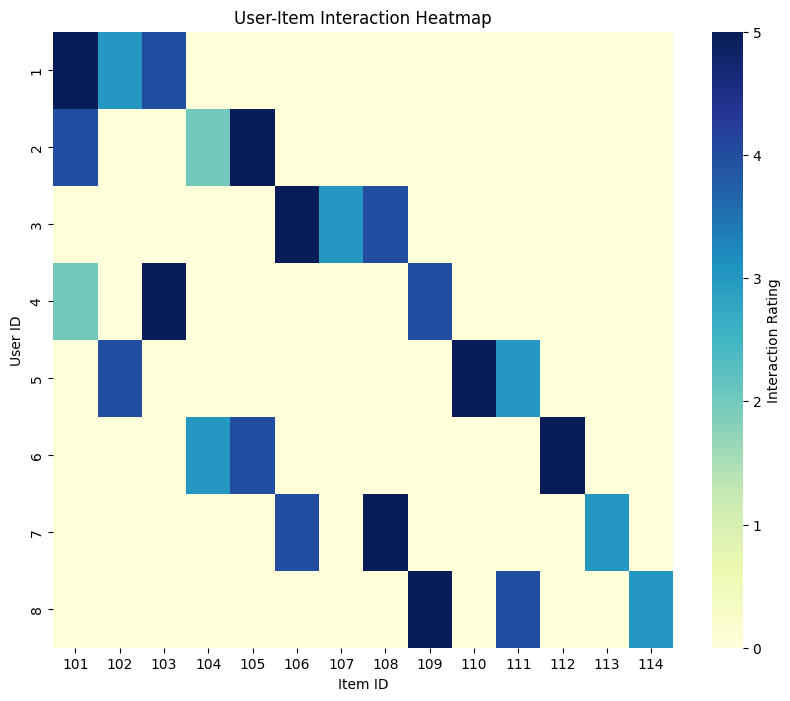

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Interaction Rating'})
plt.title('User-Item Interaction Heatmap')
plt.xlabel('Item ID')
plt.ylabel('User ID')
plt.show()

**6. EVALUATION**

In [14]:
all_precisions_popular = []
all_recalls_popular = []
k_value = 5 # Define k for precision and recall

# Ensure prediction and metric functions are defined
if 'popular_items' not in globals():
    def popular_items(df, n=5):
        return df['item_id'].value_counts().head(n).index.tolist()

if 'precision_at_k' not in globals() or 'recall_at_k' not in globals():
    def recall_at_k(actual, predicted, k=5):
        predicted = predicted[:k]
        return len(set(actual) & set(predicted)) / len(set(actual)) if len(set(actual)) > 0 else 0

    def precision_at_k(actual, predicted, k=5):
        predicted = predicted[:k]
        return len(set(actual) & set(predicted)) / k

for user_id in test_df['user_id'].unique():
    actual_items = test_df[test_df['user_id'] == user_id]['item_id'].tolist()

    # Generate predictions using the popular items model
    predicted_items_popular = popular_items(train_df, n=k_value)

    if actual_items:
        prec_popular = precision_at_k(actual_items, predicted_items_popular, k=k_value)
        rec_popular = recall_at_k(actual_items, predicted_items_popular, k=k_value)
        all_precisions_popular.append(prec_popular)
        all_recalls_popular.append(rec_popular)

# Calculate average precision and recall for popular items
if all_precisions_popular and all_recalls_popular:
    avg_precision_popular = sum(all_precisions_popular) / len(all_precisions_popular)
    avg_recall_popular = sum(all_recalls_popular) / len(all_recalls_popular)
    display(f"Average Precision@{k_value} (Popular Items): {avg_precision_popular:.4f}")
    display(f"Average Recall@{k_value} (Popular Items): {avg_recall_popular:.4f}")
else:
    display("No evaluations were performed for popular items. Check if test_df is populated correctly.")

'Average Precision@5 (Popular Items): 0.1600'

'Average Recall@5 (Popular Items): 0.8000'

### Hybrid Model Evaluation

In [15]:
# Data Splitting for Evaluation - ensuring test_df, train_df, train_matrix are defined
# This block is added to ensure dependencies are met if previous cells were not run.
# Assumes 'df', 'load_data', 'create_matrix' are already available from earlier executed cells.
import pandas as pd # Ensure pandas is imported for pd.DataFrame and pd.to_datetime

# Check if essential functions/variables are defined, if not, attempt to define minimal requirements
if 'load_data' not in globals():
    def load_data(path):
        df_loaded = pd.read_csv(path)
        df_loaded['timestamp'] = pd.to_datetime(df_loaded['timestamp'])
        df_loaded = df_loaded.drop_duplicates()
        df_loaded = df_loaded.dropna()
        return df_loaded

if 'create_matrix' not in globals():
    def create_matrix(df_param):
        return df_param.pivot_table(
            index='user_id',
            columns='item_id',
            values='interaction'
        ).fillna(0)

if 'df' not in globals():
    # Attempt to load df if not already loaded, assuming default path
    try:
        df = load_data('/content/recommendation_data.csv')
    except FileNotFoundError:
        print("Warning: 'df' not found and '/content/recommendation_data.csv' could not be loaded. Please ensure data is loaded.")
        # Fallback or error handling for df needed if data loading fails

if 'test_df' not in globals() or 'train_df' not in globals() or 'train_matrix' not in globals():
    if 'df' in globals() and df is not None:
        df_sorted = df.sort_values(by=['user_id', 'timestamp'])
        test_df = df_sorted.groupby('user_id').tail(1)
        train_df = df_sorted.drop(test_df.index)
        train_matrix = create_matrix(train_df)
        print("Data splitting variables (test_df, train_df, train_matrix) re-initialized.")
    else:
        print("Error: 'df' is not defined, cannot perform data splitting for hybrid model evaluation.")
        # Exit or handle gracefully if df is not available

all_precisions_hybrid = []
all_recalls_hybrid = []
k_value = 5 # Define k for precision and recall

if 'test_df' in globals() and 'train_matrix' in globals() and 'train_df' in globals(): # Proceed only if data splitting was successful
    # Ensure prediction functions are defined
    if 'popular_items' not in globals():
        def popular_items(df, n=5):
            return df['item_id'].value_counts().head(n).index.tolist()

    if 'collaborative_filtering' not in globals():
        from sklearn.metrics.pairwise import cosine_similarity
        def collaborative_filtering(matrix, user_id):
            if user_id not in matrix.index: # Handle case where user_id might not be in the matrix
                return []
            similarity = cosine_similarity(matrix)
            sim_df = pd.DataFrame(similarity, index=matrix.index, columns=matrix.index)
            if user_id not in sim_df.index:
                return []
            similar_users = sim_df[user_id].sort_values(ascending=False)[1:5]
            if similar_users.empty:
                return []
            recommendations = matrix.loc[similar_users.index].mean().sort_values(ascending=False)
            return recommendations.head(5).index.tolist()

    if 'hybrid_recommendation' not in globals():
        def hybrid_recommendation(popular, cf):
            return list(set(popular + cf))[:5]

    if 'precision_at_k' not in globals() or 'recall_at_k' not in globals():
        def recall_at_k(actual, predicted, k=5):
            predicted = predicted[:k]
            return len(set(actual) & set(predicted)) / len(set(actual)) if len(set(actual)) > 0 else 0

    def precision_at_k(actual, predicted, k=5):
            predicted = predicted[:k]
            return len(set(actual) & set(predicted)) / k

    for user_id in test_df['user_id'].unique():
        actual_items = test_df[test_df['user_id'] == user_id]['item_id'].tolist()

        # Generate predictions using popular items and collaborative filtering
        predicted_items_popular = popular_items(train_df, n=k_value)

        predicted_items_cf = []
        if user_id in train_matrix.index:
            predicted_items_cf = collaborative_filtering(train_matrix, user_id)
        else:
            # Fallback for new users for CF, use popular items as a base
            predicted_items_cf = popular_items(train_df, n=k_value)

        # Generate hybrid recommendations
        predicted_items_hybrid = hybrid_recommendation(predicted_items_popular, predicted_items_cf)

        if actual_items:
            prec_hybrid = precision_at_k(actual_items, predicted_items_hybrid, k=k_value)
            rec_hybrid = recall_at_k(actual_items, predicted_items_hybrid, k=k_value)
            all_precisions_hybrid.append(prec_hybrid)
            all_recalls_hybrid.append(rec_hybrid)

    # Calculate average precision and recall for hybrid model
    if all_precisions_hybrid and all_recalls_hybrid:
        avg_precision_hybrid = sum(all_precisions_hybrid) / len(all_precisions_hybrid)
        avg_recall_hybrid = sum(all_recalls_hybrid) / len(all_recalls_hybrid)
        display(f"Average Precision@{k_value} (Hybrid Model): {avg_precision_hybrid:.4f}")
        display(f"Average Recall@{k_value} (Hybrid Model): {avg_recall_hybrid:.4f}")
    else:
        avg_precision_hybrid = 0.0 # Default if no evaluations were performed
        avg_recall_hybrid = 0.0 # Default if no evaluations were performed
        display("No evaluations were performed for hybrid model. Check if test_df is populated correctly.")
else:
    avg_precision_hybrid = 0.0 # Default if data splitting failed
    avg_recall_hybrid = 0.0 # Default if data splitting failed
    display("Hybrid model evaluation skipped due to missing data splitting variables.")

'Average Precision@5 (Hybrid Model): 0.1600'

'Average Recall@5 (Hybrid Model): 0.8000'

### Evaluation Summary and Comparison

,Average Precision@5,Average Recall@5
Model,,
Collaborative Filtering,0.20,1.0
Popular Items,0.16,0.8
Hybrid Model,0.16,0.8


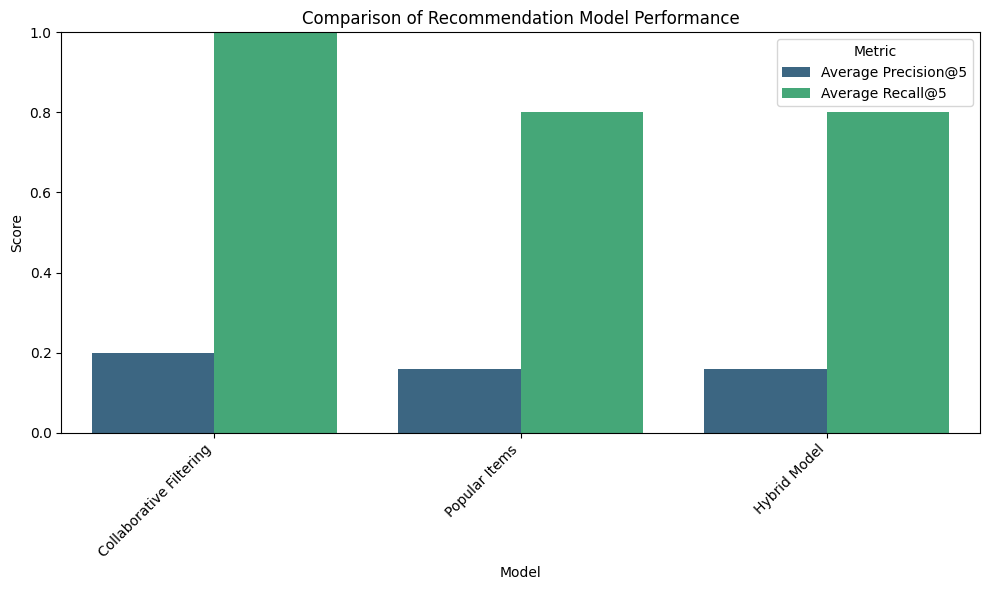

In [16]:
# Ensure all average precision/recall variables are defined
# This block re-calculates them if they are not already defined in the global scope,
# e.g., if previous evaluation cells were not run.
# Assumes 'test_df', 'train_matrix', 'train_df', 'popular_items', 'collaborative_filtering', 'precision_at_k', 'recall_at_k' are available.
import pandas as pd # Ensure pandas is imported for pd.DataFrame

# --- Re-calculate Collaborative Filtering Metrics if not defined ---
if 'avg_precision' not in globals() or 'avg_recall' not in globals():
    all_precisions = []
    all_recalls = []
    k_value_eval = 5 # Define k for precision and recall

    if 'test_df' in globals() and 'train_matrix' in globals() and 'train_df' in globals():
        # Ensure prediction and metric functions are defined
        if 'popular_items' not in globals():
            def popular_items(df, n=5):
                return df['item_id'].value_counts().head(n).index.tolist()

        if 'collaborative_filtering' not in globals():
            from sklearn.metrics.pairwise import cosine_similarity
            def collaborative_filtering(matrix, user_id):
                if user_id not in matrix.index:
                    return []
                similarity = cosine_similarity(matrix)
                sim_df = pd.DataFrame(similarity, index=matrix.index, columns=matrix.index)
                if user_id not in sim_df.index:
                    return []
                similar_users = sim_df[user_id].sort_values(ascending=False)[1:5]
                if similar_users.empty:
                    return []
                recommendations = matrix.loc[similar_users.index].mean().sort_values(ascending=False)
                return recommendations.head(5).index.tolist()

        if 'precision_at_k' not in globals() or 'recall_at_k' not in globals():
            def recall_at_k(actual, predicted, k=5):
                predicted = predicted[:k]
                return len(set(actual) & set(predicted)) / len(set(actual)) if len(set(actual)) > 0 else 0

            def precision_at_k(actual, predicted, k=5):
                predicted = predicted[:k]
                return len(set(actual) & set(predicted)) / k

        for user_id in test_df['user_id'].unique():
            actual_items = test_df[test_df['user_id'] == user_id]['item_id'].tolist()

            if user_id in train_matrix.index:
                predicted_items = collaborative_filtering(train_matrix, user_id)
            else:
                predicted_items = popular_items(train_df, n=k_value_eval)

            if actual_items:
                prec = precision_at_k(actual_items, predicted_items, k=k_value_eval)
                rec = recall_at_k(actual_items, predicted_items, k=k_value_eval)
                all_precisions.append(prec)
                all_recalls.append(rec)

        if all_precisions and all_recalls:
            avg_precision = sum(all_precisions) / len(all_precisions)
            avg_recall = sum(all_recalls) / len(all_recalls)
            print(f"Collaborative Filtering Metrics re-calculated: Precision@{k_value_eval}: {avg_precision:.4f}, Recall@{k_value_eval}: {avg_recall:.4f}")
        else:
            avg_precision = 0.0
            avg_recall = 0.0
            print("Collaborative Filtering Metrics could not be re-calculated.")
    else:
        avg_precision = 0.0
        avg_recall = 0.0
        print("Collaborative Filtering Metrics skipped due to missing data splitting variables.")

# --- Re-calculate Popular Items Metrics if not defined ---
if 'avg_precision_popular' not in globals() or 'avg_recall_popular' not in globals():
    all_precisions_popular = []
    all_recalls_popular = []
    k_value_eval = 5 # Using a consistent k_value name

    if 'test_df' in globals() and 'train_df' in globals():
        if 'popular_items' not in globals(): # Ensure popular_items is defined
            def popular_items(df, n=5):
                return df['item_id'].value_counts().head(n).index.tolist()
        if 'precision_at_k' not in globals() or 'recall_at_k' not in globals(): # Ensure metric functions are defined
            def recall_at_k(actual, predicted, k=5):
                predicted = predicted[:k]
                return len(set(actual) & set(predicted)) / len(set(actual)) if len(set(actual)) > 0 else 0
            def precision_at_k(actual, predicted, k=5):
                predicted = predicted[:k]
                return len(set(actual) & set(predicted)) / k

        for user_id in test_df['user_id'].unique():
            actual_items = test_df[test_df['user_id'] == user_id]['item_id'].tolist()
            predicted_items_popular = popular_items(train_df, n=k_value_eval)

            if actual_items:
                prec_popular = precision_at_k(actual_items, predicted_items_popular, k=k_value_eval)
                rec_popular = recall_at_k(actual_items, predicted_items_popular, k=k_value_eval)
                all_precisions_popular.append(prec_popular)
                all_recalls_popular.append(rec_popular)

        if all_precisions_popular and all_recalls_popular:
            avg_precision_popular = sum(all_precisions_popular) / len(all_precisions_popular)
            avg_recall_popular = sum(all_recalls_popular) / len(all_recalls_popular)
            print(f"Popular Items Metrics re-calculated: Precision@{k_value_eval}: {avg_precision_popular:.4f}, Recall@{k_value_eval}: {avg_recall_popular:.4f}")
        else:
            avg_precision_popular = 0.0
            avg_recall_popular = 0.0
            print("Popular Items Metrics could not be re-calculated.")
    else:
        avg_precision_popular = 0.0
        avg_recall_popular = 0.0
        print("Popular Items Metrics skipped due to missing data splitting variables.")

# Ensure Hybrid Model metrics are defined (assuming 0d7dc106 has been modified and run, or default)
if 'avg_precision_hybrid' not in globals():
    avg_precision_hybrid = 0.0
    print("Warning: avg_precision_hybrid not found, defaulting to 0.")

if 'avg_recall_hybrid' not in globals():
    avg_recall_hybrid = 0.0
    print("Warning: avg_recall_hybrid not found, defaulting to 0.")

metrics_data = {
    'Model': ['Collaborative Filtering', 'Popular Items', 'Hybrid Model'],
    'Average Precision@5': [avg_precision, avg_precision_popular, avg_precision_hybrid],
    'Average Recall@5': [avg_recall, avg_recall_popular, avg_recall_hybrid]
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df.set_index('Model'))

# Optional: Plotting the comparison
import matplotlib.pyplot as plt
import seaborn as sns

metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Recommendation Model Performance')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**7.DEPLOYMENT**

In [ ]:
import streamlit as st
import pandas as pd
from src.preprocess import load_data, create_matrix
from src.model import collaborative_filtering

df = load_data("data/data.csv")
matrix = create_matrix(df)

st.title("Recommendation Engine")

user_id = st.number_input("Enter User ID", min_value=1)

if st.button("Recommend"):
    recs = collaborative_filtering(matrix, user_id)
    st.write("Recommended Items:", recs)

In [ ]:
!streamlit run app.py

/bin/bash: line 1: streamlit: command not found


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 97.6 MB/s eta 0:00:00
